In [315]:
import scipy.io
from scipy.stats import ks_2samp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    confusion_matrix, precision_score, recall_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)

import matplotlib.lines as mlines

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 11,
    "font.size": 11,
    "figure.dpi": 120,
})

mat_path = '../datasets/archetypometricsdata2000.mat'

N_TRAITS = 300   # number of trait dimensions to use (max 464)

In [316]:
mat = scipy.io.loadmat(str(mat_path), simplify_cells=True)

archetype_space = mat["data_raw"]["A"]  # (464, 2000)
trait_names_raw = mat["data_traits"]["trait_typenames"]                     # (464,)

def sanitize(name):
    return name.replace(' :: ', '__').replace(' ', '_').replace('-', '_')

trait_names = [sanitize(n) for n in trait_names_raw[:N_TRAITS]]
print(f"Using {N_TRAITS} of {archetype_space.shape[0]} available trait dimensions")
print(f"Sample trait names: {trait_names[:5]}")

ds = mat["data_stories"]
story_names_arr = ds["storyverses"]
story_char_idx  = ds["storycharacterindices"]
story_index = {
    story_names_arr[i]: (story_char_idx[i] - 1)
    for i in range(len(story_names_arr))
}

story_imdb = pd.read_csv('../prepared_data/story_imdb_mapping.csv')
# story_genre = pd.read_csv('../prepared_data/story_imdb_mapping.csv')

# story_genre['genre_label'] = story_genre['imdb_genres'].apply(lambda x: 'Comedy' if 'Comedy' in str(x) else ('Drama' if 'Drama' in str(x) else 'Unknown'))

genres    = story_imdb.groupby("story_name")["imdb_genres"].first().fillna("")
is_comedy = genres.str.contains("Comedy")
is_drama  = genres.str.contains("Drama")
pure      = is_comedy ^ is_drama
genre_labels = is_comedy[pure].astype(int)

# hl = pd.read_csv('../prepared_data/hand_labels.csv')
# hl = hl.dropna(subset=["label"])
# hl = hl[hl["label"].astype(str).str.strip().isin(["0", "1", "0.0", "1.0"])]
# hl["label"] = hl["label"].astype(float).astype(int)
# hl = hl.set_index("story_name")["label"]
# genre_labels = hl.combine_first(genre_labels).astype(int)

print(f"\nLabeled stories: {len(genre_labels)}  (comedy={genre_labels.sum()}, drama={(genre_labels==0).sum()})")

Using 300 of 464 available trait dimensions
Sample trait names: ['playful__serious', 'shy__bold', 'cheery__sorrowful', 'masculine__feminine', 'charming__awkward']

Labeled stories: 203  (comedy=65, drama=138)


In [317]:
def radius_gyration(A):
    centroid = np.mean(A, axis=1, keepdims=True)
    differences = A - centroid
    squared_distances = np.sum(differences ** 2, axis=0)
    return np.sqrt(np.mean(squared_distances))

rows = []
for story_name, is_comedy_val in genre_labels.items():
    if story_name not in story_index:
        continue

    char_idx = np.atleast_1d(story_index[story_name])
    scores   = archetype_space[:N_TRAITS, char_idx]  # (N_TRAITS, n_chars)

    n_chars = len(char_idx)
    row = {"story_name": story_name, "is_comedy": int(is_comedy_val), "cast_size": n_chars}

    for j, trait in enumerate(trait_names):
        row[f"{trait}_mean"] = scores[j].mean()

    row["cast_gyration"] = radius_gyration(scores)
    rows.append(row)

df = pd.DataFrame(rows).set_index("story_name")
print(f"Stories: {len(df)},  Columns: {df.shape[1]}  ({N_TRAITS} trait means + cast_size + cast_gyration + is_comedy)")
df.head(3)

# print sum of cast size by genre
print("\nTotal cast size by genre:")
print(df.groupby("is_comedy")["cast_size"].sum())   
print (828 + 352)

# print average cast size by genre
print("\nAverage cast size by genre:")
print(df.groupby("is_comedy")["cast_size"].mean())

Stories: 203,  Columns: 303  (300 trait means + cast_size + cast_gyration + is_comedy)

Total cast size by genre:
is_comedy
0    828
1    352
Name: cast_size, dtype: int64
1180

Average cast size by genre:
is_comedy
0    6.000000
1    5.415385
Name: cast_size, dtype: float64


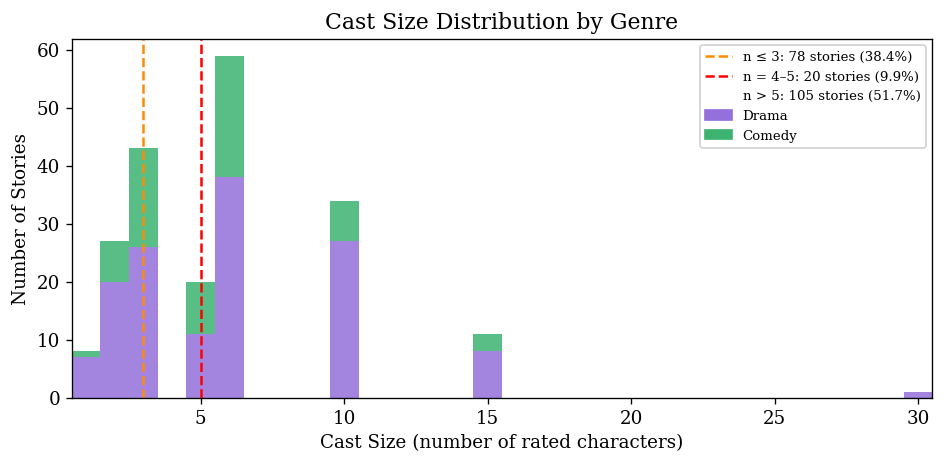

In [318]:
fig, ax = plt.subplots(figsize=(8, 4))

# Separate by genre — adjust column/value names to match your df
# drama = df[df['genre'] == 'Drama']['cast_size']
# comedy = df[df['genre'] == 'Comedy']['cast_size']
drama = df[df['is_comedy'] == 0]['cast_size']
comedy = df[df['is_comedy'] == 1]['cast_size']

bins = np.arange(0.5, df['cast_size'].max() + 1.5, 1)

ax.hist([drama, comedy], bins=bins, stacked=True,
        color=['mediumpurple', 'mediumseagreen'],
        alpha=0.85, label=['Drama', 'Comedy'])

# Threshold lines — adjust values to match your paper's thresholds
t1, t2 = 3, 5
ax.axvline(x=t1, color='darkorange', linestyle='--', linewidth=1.5)
ax.axvline(x=t2, color='red',        linestyle='--', linewidth=1.5)

# Group counts for legend annotations
total = len(df)
n_le_t1  = (df['cast_size'] <= t1).sum()
n_mid    = ((df['cast_size'] > t1) & (df['cast_size'] <= t2)).sum()
n_gt_t2  = (df['cast_size'] > t2).sum()

# Build legend handles
drama_patch  = mpatches.Patch(color='mediumpurple',  label='Drama')
comedy_patch = mpatches.Patch(color='mediumseagreen', label='Comedy')

line_t1 = mlines.Line2D([], [], color='darkorange', linestyle='--',
                         label=f'n ≤ {t1}: {n_le_t1} stories ({n_le_t1/total*100:.1f}%)')
line_t2 = mlines.Line2D([], [], color='red', linestyle='--',
                         label=f'n = {t1+1}–{t2}: {n_mid} stories ({n_mid/total*100:.1f}%)')
label_gt = mpatches.Patch(visible=False,
                           label=f'n > {t2}: {n_gt_t2} stories ({n_gt_t2/total*100:.1f}%)')

ax.legend(handles=[line_t1, line_t2, label_gt, drama_patch, comedy_patch],
          fontsize=8, framealpha=0.9)

ax.set_title('Cast Size Distribution by Genre')
ax.set_xlabel('Cast Size (number of rated characters)')
ax.set_ylabel('Number of Stories')
ax.set_xlim(0.5, df['cast_size'].max() + 0.5)

plt.tight_layout()
plt.savefig('../figures/cast_size_by_genre.png', bbox_inches='tight')
plt.show()

In [319]:
comedy = df[df['is_comedy'] == 1]
drama  = df[df['is_comedy'] == 0]

feature_cols = [c for c in df.columns if c != 'is_comedy']
results = []
for col in feature_cols:
    stat, pval = ks_2samp(comedy[col].values, drama[col].values)
    results.append({'feature': col, 'ks_stat': stat, 'p_value': pval})

ks_df = (pd.DataFrame(results)
           .sort_values('ks_stat', ascending=False)
           .reset_index(drop=True))
ks_df['significant'] = ks_df['p_value'] < 0.05

print(f"Significant features (p < 0.05): {ks_df['significant'].sum()} / {len(ks_df)}")
print("\nTop 20 most discriminating traits:")
ks_df.head(20).round(4)

Significant features (p < 0.05): 163 / 302

Top 20 most discriminating traits:


,feature,ks_stat,p_value,significant
0,comedic__dramatic_mean,0.5517,0.0,True
1,epic__deep_mean,0.5319,0.0,True
2,secretive__open_book_mean,0.4957,0.0,True
3,zany__regular_mean,0.4957,0.0,True
4,cheery__sorrowful_mean,0.4957,0.0,True
5,chatty__reserved_mean,0.4894,0.0,True
6,funny__humorless_mean,0.4893,0.0,True
7,stoic__expressive_mean,0.4794,0.0,True
8,open__guarded_mean,0.4785,0.0,True
9,sunny__gloomy_mean,0.4766,0.0,True


  The dataset has a class imbalance — more dramas than comedies (or vice versa). By default, logistic
  regression treats every misclassification equally, which biases the model toward the majority class (it can
  get decent accuracy just by always predicting drama).

  class_weight='balanced' tells sklearn to automatically reweight each training sample inversely proportional
  to class frequency:

  weight for class c = n_samples / (n_classes * n_samples_in_class_c)

  So the minority class gets a higher penalty when misclassified, forcing the model to take it seriously.
  Without this, you'd likely see poor recall on whichever genre appears less.

  ---
  C=0.01 (in the grid search; C=0.1 is BEST_C)

  C is the inverse regularization strength in sklearn's logistic regression. We are in a high-dimensional
  regime — 466 features from raw traits but only 203 samples — so unconstrained, the model can overfit badly.

  - Small C (e.g., 0.01) → strong L2 regularization → coefficients are pulled hard toward zero → simpler, more
  conservative model
  - Large C (e.g., 1.0 or 10.0) → weak regularization → model is free to chase the training data

  The notebook sweeps [0.01, 0.1, 1.0] and picks C=0.1 as BEST_C based on cross-validated AUC, which is the
  sweet spot between underfitting (C=0.01) and overfitting (C=1.0) for your feature-to-sample ratio.

In [320]:
target       = 'is_comedy'
all_feat_cols = [c for c in df.columns if c != target]

X_all = df[all_feat_cols].values
y     = df[target].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare regularization strengths — with 466 features and 247 samples, C matters
results_cv = []
for C in [0.01, 0.1, 1.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(max_iter=2000, C=C, class_weight='balanced'))
    ])
    scores = cross_validate(pipe, X_all, y, cv=cv,
                            scoring=['roc_auc', 'f1', 'accuracy'])
    results_cv.append({
        'C (regularization)': C,
        'AUC':      scores['test_roc_auc'].mean(),
        'AUC_std':  scores['test_roc_auc'].std(),
        'F1':       scores['test_f1'].mean(),
        'F1_std':   scores['test_f1'].std(),
        'Accuracy': scores['test_accuracy'].mean(),
        'Acc_std':  scores['test_accuracy'].std(),
    })

pd.DataFrame(results_cv).round(3)

,C (regularization),AUC,AUC_std,F1,F1_std,Accuracy,Acc_std
0,0.01,0.879,0.054,0.700,0.062,0.798,0.030
1,0.10,0.893,0.072,0.716,0.110,0.813,0.057
2,1.00,0.890,0.075,0.707,0.092,0.808,0.043


In [321]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

BEST_C = 0.1

all_y_test = []
all_y_pred = []

for train_idx, test_idx in cv.split(X_all, y):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000, C=BEST_C, class_weight='balanced')
    clf.fit(X_tr_sc, y_train)

    all_y_test.extend(y_test)
    all_y_pred.extend(clf.predict(X_te_sc))

all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_test, all_y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"{'':25s} Predicted Comedy  Predicted Drama")
print(f"{'Actual Comedy':25s} {tp:^16d}  {fn:^15d}")
print(f"{'Actual Drama':25s} {fp:^16d}  {tn:^15d}")
print(f"\nPrecision: {precision_score(all_y_test, all_y_pred):.3f}")
print(f"Recall:    {recall_score(all_y_test, all_y_pred):.3f}")
print(f"F1:        {f1_score(all_y_test, all_y_pred):.3f}")
print(f"Accuracy:  {accuracy_score(all_y_test, all_y_pred):.3f}")

                          Predicted Comedy  Predicted Drama
Actual Comedy                    50               15       
Actual Drama                     23               115      

Precision: 0.685
Recall:    0.769
F1:        0.725
Accuracy:  0.813


In [322]:
# Use C=0.1 (stronger regularization) given high dimensionality
BEST_C = 0.1

np.random.seed(42)
fold_results  = []
all_y_test    = []
all_y_pred    = []
fold_tprs     = []
fold_aucs     = []
fold_precs    = []
fold_aps      = []
mean_fpr      = np.linspace(0, 1, 300)
mean_recall   = np.linspace(0, 1, 300)

for train_idx, test_idx in cv.split(X_all, y):
    X_train, X_test = X_all[train_idx], X_all[test_idx]
    y_train, y_test = y[train_idx],     y[test_idx]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000, C=BEST_C, class_weight='balanced')
    clf.fit(X_tr_sc, y_train)

    y_pred = clf.predict(X_te_sc)
    y_prob = clf.predict_proba(X_te_sc)[:, 1]

    all_y_test.extend(y_test)
    all_y_pred.extend(y_pred)

    fold_results.append({
        'AUC':      roc_auc_score(y_test, y_prob),
        'F1':       f1_score(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
    })

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    fold_tprs.append(np.interp(mean_fpr, fpr, tpr))
    fold_tprs[-1][0] = 0.0
    fold_aucs.append(auc(fpr, tpr))

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    fold_precs.append(np.interp(mean_recall, recall[::-1], precision[::-1]))
    fold_aps.append(average_precision_score(y_test, y_prob))

print("All-trait model (class_weight='balanced', C=0.1):")
pd.DataFrame(fold_results).describe().loc[['mean', 'std']].round(3)

All-trait model (class_weight='balanced', C=0.1):


,AUC,F1,Accuracy
mean,0.893,0.716,0.813
std,0.080,0.123,0.064


In [323]:
all_y_test = np.array(all_y_test)
all_y_pred = np.array(all_y_pred)

cm = confusion_matrix(all_y_test, all_y_pred)
tn, fp, fn, tp = cm.ravel()

print("Pooled confusion matrix (5-fold CV):")
print(f"\n{'':25s} Predicted Comedy  Predicted Drama")
print(f"{'Actual Comedy':25s} {tp:^16d}  {fn:^15d}")
print(f"{'Actual Drama':25s} {fp:^16d}  {tn:^15d}")

prec = precision_score(all_y_test, all_y_pred)
rec  = recall_score(all_y_test, all_y_pred)
f1   = f1_score(all_y_test, all_y_pred)
acc  = accuracy_score(all_y_test, all_y_pred)
print(f"\nPrecision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1:.3f}  Accuracy: {acc:.3f}")

Pooled confusion matrix (5-fold CV):

                          Predicted Comedy  Predicted Drama
Actual Comedy                    50               15       
Actual Drama                     23               115      

Precision: 0.685  Recall: 0.769  F1: 0.725  Accuracy: 0.813


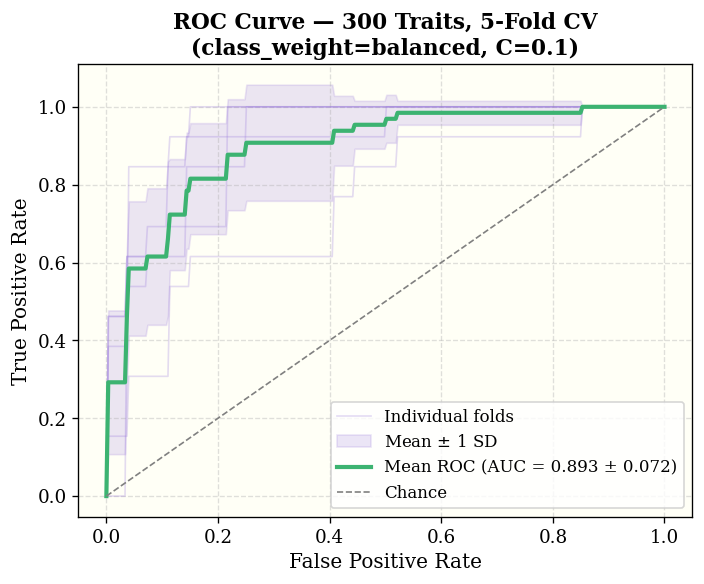

In [324]:
mean_tpr      = np.mean(fold_tprs, axis=0)
mean_tpr[-1]  = 1.0
std_tpr       = np.std(fold_tprs, axis=0)

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, tpr_fold in enumerate(fold_tprs):
    ax.plot(mean_fpr, tpr_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_fpr, mean_tpr, color='mediumseagreen', linewidth=2.5,
        label=f'Mean ROC (AUC = {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Chance')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curve — {N_TRAITS} Traits, 5-Fold CV\n(class_weight=balanced, C={BEST_C})', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_roc_all_traits.png', dpi=300)
plt.show()

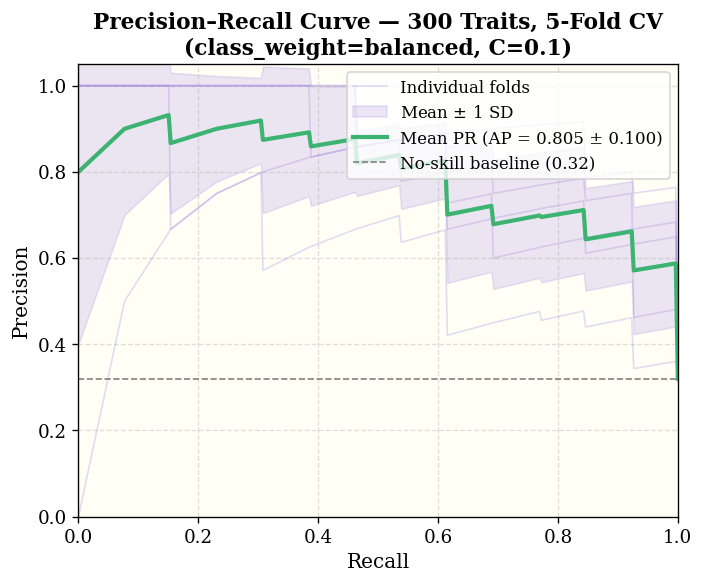

In [325]:
mean_precision      = np.mean(fold_precs, axis=0)
std_precision       = np.std(fold_precs, axis=0)
baseline_precision  = y.mean()

fig, ax = plt.subplots(figsize=(6, 5))
ax.set_facecolor((1.0, 1.0, 0.965))

for i, prec_fold in enumerate(fold_precs):
    ax.plot(mean_recall, prec_fold, color='mediumpurple', alpha=0.25, linewidth=1,
            label='Individual folds' if i == 0 else None)

ax.fill_between(mean_recall, mean_precision - std_precision, mean_precision + std_precision,
                color='mediumpurple', alpha=0.18, label=r'Mean $\pm$ 1 SD')
ax.plot(mean_recall, mean_precision, color='mediumseagreen', linewidth=2.5,
        label=f'Mean PR (AP = {np.mean(fold_aps):.3f} ± {np.std(fold_aps):.3f})')
ax.axhline(baseline_precision, linestyle='--', color='gray', linewidth=1,
           label=f'No-skill baseline ({baseline_precision:.2f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title(f'Precision–Recall Curve — {N_TRAITS} Traits, 5-Fold CV\n(class_weight=balanced, C={BEST_C})', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/genre_prediction_pr_all_traits.png', dpi=300)
plt.show()

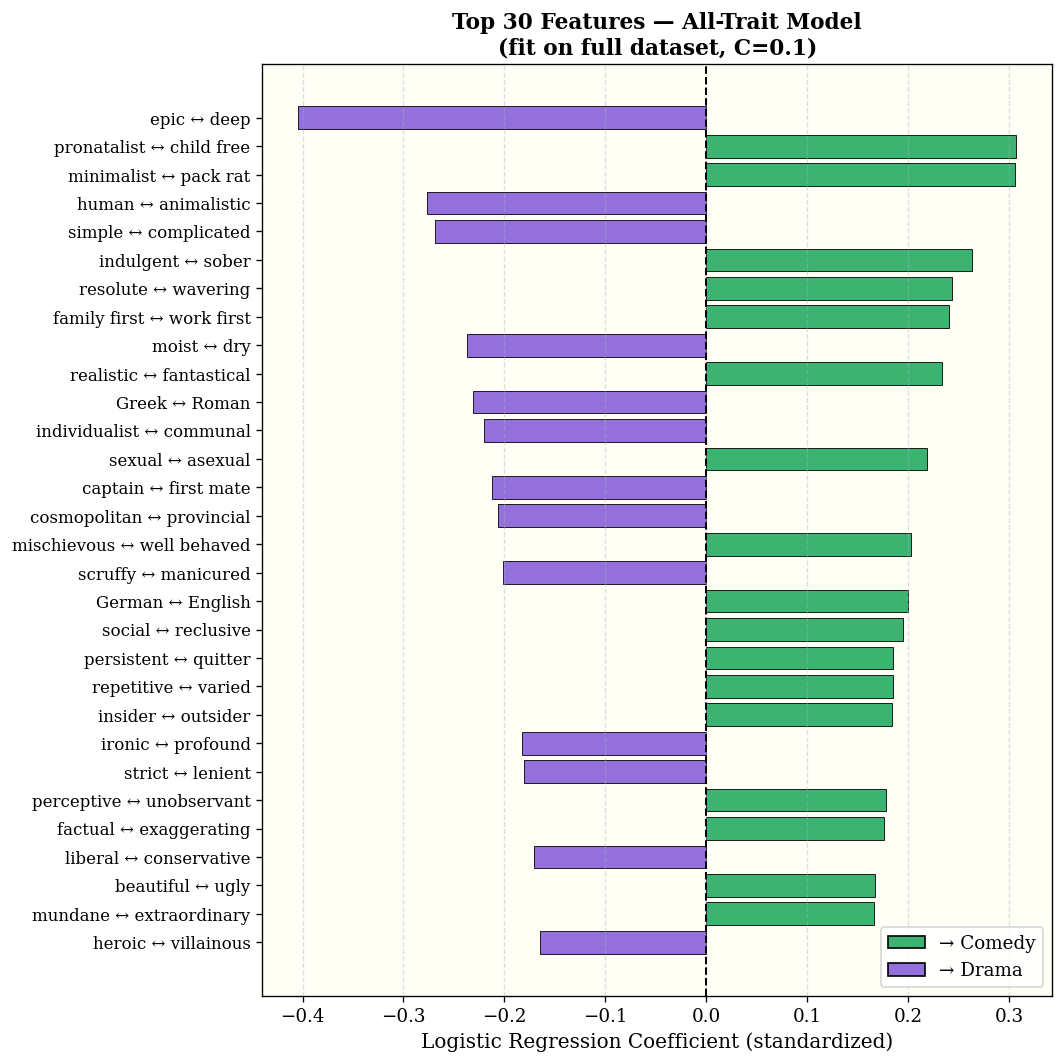

In [326]:
# Top 30 traits by coefficient magnitude (fit on full dataset)
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X_all)
clf_full = LogisticRegression(max_iter=2000, C=BEST_C, class_weight='balanced')
clf_full.fit(X_scaled_full, y)

coefs  = clf_full.coef_[0]
labels = [c.replace('_mean', '').replace('__', ' ↔ ').replace('_', ' ') for c in all_feat_cols]

top_n  = 30
order  = np.argsort(np.abs(coefs))[-top_n:]
coefs_sorted  = coefs[order]
labels_sorted = [labels[i] for i in order]
colors = ['mediumseagreen' if c > 0 else 'mediumpurple' for c in coefs_sorted]

fig, ax = plt.subplots(figsize=(9, 9))
ax.set_facecolor((1.0, 1.0, 0.965))
ax.barh(range(top_n), coefs_sorted, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(top_n))
ax.set_yticklabels(labels_sorted, fontsize=10)
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel("Logistic Regression Coefficient (standardized)", fontsize=12)
ax.set_title(
    f"Top {top_n} Features — All-Trait Model\n(fit on full dataset, C={BEST_C})",
    fontsize=13, fontweight='bold'
)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)

comedy_patch = mpatches.Patch(facecolor='mediumseagreen', edgecolor='black', label='→ Comedy')
drama_patch  = mpatches.Patch(facecolor='mediumpurple',   edgecolor='black', label='→ Drama')
ax.legend(handles=[comedy_patch, drama_patch], fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/logistic_coef_all_traits.png', dpi=300)
plt.show()

In [327]:
# Print top N coefficients as a table for LaTeX
print(f"{'Feature':<40} {'Coefficient':>12} {'Direction':>15}")
print("-" * 70)
for i in reversed(range(top_n)):  # reversed so highest magnitude is first
    label = labels_sorted[i]
    coef  = coefs_sorted[i]
    direction = "Comedy" if coef > 0 else "Drama"
    print(f"{label:<40} {coef:>12.4f} {direction:>15}")

Feature                                   Coefficient       Direction
----------------------------------------------------------------------
epic ↔ deep                                   -0.4044           Drama
pronatalist ↔ child free                       0.3074          Comedy
minimalist ↔ pack rat                          0.3055          Comedy
human ↔ animalistic                           -0.2763           Drama
simple ↔ complicated                          -0.2683           Drama
indulgent ↔ sober                              0.2636          Comedy
resolute ↔ wavering                            0.2435          Comedy
family first ↔ work first                      0.2404          Comedy
moist ↔ dry                                   -0.2372           Drama
realistic ↔ fantastical                        0.2336          Comedy
Greek ↔ Roman                                 -0.2307           Drama
individualist ↔ communal                      -0.2197           Drama
sexual ↔ asexual   

n=   6  AUC=0.850 ± 0.056  F1=0.673 ± 0.088
n=  10  AUC=0.849 ± 0.060  F1=0.666 ± 0.096
n=  20  AUC=0.831 ± 0.058  F1=0.676 ± 0.083
n=  30  AUC=0.828 ± 0.062  F1=0.686 ± 0.090
n=  50  AUC=0.836 ± 0.071  F1=0.681 ± 0.097
n=  75  AUC=0.816 ± 0.080  F1=0.655 ± 0.075
n= 100  AUC=0.825 ± 0.079  F1=0.647 ± 0.089
n= 150  AUC=0.850 ± 0.070  F1=0.676 ± 0.100
n= 200  AUC=0.871 ± 0.065  F1=0.706 ± 0.095
n= 300  AUC=0.893 ± 0.072  F1=0.716 ± 0.110


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: invalid value encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights


n= 400  AUC=0.885 ± 0.068  F1=0.747 ± 0.112
n= 464  AUC=0.881 ± 0.077  F1=0.738 ± 0.110


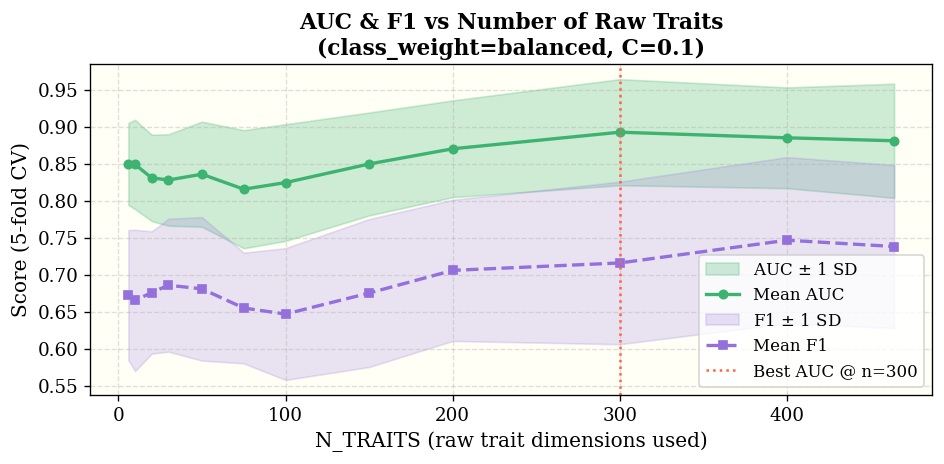


Best AUC: 0.893 at N_TRAITS=300


In [328]:
trait_counts  = [6, 10, 20, 30, 50, 75, 100, 150, 200, 300, 400, 464]
sweep_results = []

for n in trait_counts:
    trait_names_n = [sanitize(t) for t in trait_names_raw[:n]]
    rows_n = []
    for story_name, is_comedy_val in genre_labels.items():
        if story_name not in story_index:
            continue
        char_idx = np.atleast_1d(story_index[story_name])
        scores   = mat["data_raw"]["A"][:n, char_idx]
        row = {"is_comedy": int(is_comedy_val), "cast_size": len(char_idx)}
        for j, trait in enumerate(trait_names_n):
            row[f"{trait}_mean"] = scores[j].mean()
        row["cast_gyration"] = radius_gyration(scores)
        rows_n.append(row)

    df_n  = pd.DataFrame(rows_n)
    X_n   = df_n.drop(columns="is_comedy").values
    y_n   = df_n["is_comedy"].values

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    LogisticRegression(max_iter=2000, C=BEST_C, class_weight="balanced")),
    ])
    s = cross_validate(pipe, X_n, y_n, cv=cv, scoring=["roc_auc", "f1"])
    sweep_results.append({
        "n_traits": n,
        "auc_mean": s["test_roc_auc"].mean(),
        "auc_std":  s["test_roc_auc"].std(),
        "f1_mean":  s["test_f1"].mean(),
        "f1_std":   s["test_f1"].std(),
    })
    print(f"n={n:4d}  AUC={s['test_roc_auc'].mean():.3f} \u00b1 {s['test_roc_auc'].std():.3f}"
          f"  F1={s['test_f1'].mean():.3f} \u00b1 {s['test_f1'].std():.3f}")

sweep_df = pd.DataFrame(sweep_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor((1.0, 1.0, 0.965))

ax.fill_between(sweep_df["n_traits"],
                sweep_df["auc_mean"] - sweep_df["auc_std"],
                sweep_df["auc_mean"] + sweep_df["auc_std"],
                alpha=0.25, color="mediumseagreen", label=r"AUC $\pm$ 1 SD")
ax.plot(sweep_df["n_traits"], sweep_df["auc_mean"],
        color="mediumseagreen", linewidth=2, marker="o", markersize=5, label="Mean AUC")

ax.fill_between(sweep_df["n_traits"],
                sweep_df["f1_mean"] - sweep_df["f1_std"],
                sweep_df["f1_mean"] + sweep_df["f1_std"],
                alpha=0.2, color="mediumpurple", label=r"F1 $\pm$ 1 SD")
ax.plot(sweep_df["n_traits"], sweep_df["f1_mean"],
        color="mediumpurple", linewidth=2, marker="s", markersize=5,
        linestyle="--", label="Mean F1")

best_idx = sweep_df["auc_mean"].idxmax()
best_n   = sweep_df.loc[best_idx, "n_traits"]
best_auc = sweep_df.loc[best_idx, "auc_mean"]
ax.axvline(best_n, color="tomato", linestyle=":", linewidth=1.5,
           label=f"Best AUC @ n={best_n}")

ax.set_xlabel("N_TRAITS (raw trait dimensions used)", fontsize=12)
ax.set_ylabel("Score (5-fold CV)", fontsize=12)
ax.set_title(f"AUC & F1 vs Number of Raw Traits\n(class_weight=balanced, C={BEST_C})",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("../figures/auc_vs_n_traits.png", dpi=300)
plt.show()

print(f"\nBest AUC: {best_auc:.3f} at N_TRAITS={best_n}")